In [1]:
library(nlme)
suppressMessages(suppressWarnings(library('emmeans')))
suppressMessages(suppressWarnings(library('car')))
suppressMessages(suppressWarnings(library('effects')))

ratpup           <- read.table('rat_pup.dat', header=TRUE)
ratpup$sex       <- as.factor(ratpup$sex)
ratpup$litter    <- as.factor(ratpup$litter)
ratpup$treatment <- as.factor(ratpup$treatment)

# Implementing the Model in `R`
As a final part of this lesson, we will see the process of fitting the model we have developed for the `ratpup` dataset using the `lme()` function in `R`. Despite the time spent building and considering this model, we will see that the specification and fitting process is deceptively quick. In a way, this belies the complexity and thought that sits behind the model. This is why the temptation is often to skip this process, especially when introducing these methods to students. However, skipping these steps can lead to confusion, conceptual misunderstandings and knowledge gaps. This is the reason why we have spent so long building to this point, rather than jumping straight to the `R` code.

## Collapsing to Mixed-effects Form
As we know, in order to fit a multilevel model using `lme()`, we need to collapse over the levels and specify the model in mixed-effects form. Our current two-level model is given below, where you can flip between the generic notation and the data labels using the tabs.

````{tab-set}
```{tab-item} Generic Notation
$$
\begin{alignat*}{1}
    \text{Level 1} \\
    y^{(k)}_{ij}     &= \mu^{(k)} + \alpha^{(k)}_{j} + \eta^{(k)}_{ij}  \\
    \quad \\
    \text{Level 2} \\
    \mu^{(k)}        &= \mu + \beta_{l} + \xi^{(k)}  \\
    \alpha^{(k)}_{j} &= \alpha_{j} + (\alpha\beta)_{jl} + \phi^{(k)}_{j}
\end{alignat*}
$$
```

```{tab-item} Data Labels
$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{weight}^{(k)}_{ij}     &= \text{mean}^{(k)} + \text{sex}^{(k)}_{j} + \eta^{(k)}_{ij}  \\
    \quad \\
    \text{Level 2} \\
    \text{mean}^{(k)}    &= \text{mean} + \text{treatment}_{l} + \xi^{(k)}  \\
    \text{sex}^{(k)}_{j} &= \text{sex}_{j} + (\text{sex} \times \text{treatment})_{jl} + \phi^{(k)}_{j}
\end{alignat*}
$$
```
````

In order to turn this into a single-level mixed-effects models, we simply replace the terms at Level 1 with their equalities at Level 2. This is shown below

````{tab-set}
```{tab-item} Generic Notation
$$
y^{(k)}_{ij} = \overbrace{\mu + \beta_{l} + \xi^{(k)}}^{\mu^{(k)}} + \overbrace{\alpha_{j} + (\alpha\beta)_{jl} + \phi^{(k)}_{j}}^{\alpha^{(k)}_{j}} + \eta^{(k)}_{ij}
$$
```

```{tab-item} Data Labels
$$
\text{weight}^{(k)}_{ij} = \overbrace{\text{mean} + \text{treatment}_{l} + \xi^{(k)}}^{\text{mean}^{(k)}} + \overbrace{\text{sex}_{j} + (\text{sex} \times \text{treatment})_{jl} + \phi^{(k)}_{j}}^{\text{sex}^{(k)}_{j}} + \eta^{(k)}_{ij}
$$
```
````

Finally, we collect like-terms together such that the *fixed* elements are together and the *random* elements are together. This is not strictly necessary, but makes the model easier to understand.

````{tab-set}
```{tab-item} Generic Notation
$$
y^{(k)}_{ij} = \overbrace{\mu + \alpha_{j} + \beta_{l} + (\alpha\beta)_{jl}}^{\text{fixed-effects}} + \overbrace{\xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij}}^{\text{random-effects}}
$$
```

```{tab-item} Data Labels
$$
\text{weight}^{(k)}_{ij} = \overbrace{\text{mean} + \text{sex}_{j} + \text{treatment}_{l} + (\text{sex} \times \text{treatment})_{jl}}^{\text{fixed-effects}} + \overbrace{\xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij}}^{\text{random-effects}}
$$
```
````


## Specifying the Random-effects
Given the mixed-effects form above, we need to think about how we express the random-effects to `lme()`. The fixed effects are easy, because this will just be `weight ~ 1 + sex + treatment + sex:treatment`. So, no different to what we have seen previously and effectively what we can see written above. However, the random-effects are currently written as

$$
\xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij},
$$

which need a moment's thought in order to turn them into something `lme()` can use.

To begin with, no matter what we specify there will always be a final error term. This is the same as any regression model. We never tell `lm()` of `gls()` that we want errors because they are a fundamental component of the model. So, we do not need to worry about the final error term $\eta^{(k)}_{ij}$[^finalerror-foot]. Because of this, all we really need to tell `lme()` about is

$$
\xi^{(k)} + \phi^{(k)}_{j}.
$$

Now, notice that both of these terms relate to a specific litter $k$, so another way of writing them would be *conditional* on the value of $k$

$$
\xi + \phi_{j}\, |\, k.
$$

Now that we have moved $(k)$ out of the way, it starts to become clearer what these terms mean within a single litter. For a given litter $k$, we have a *constant value* called $\xi$ and an *effect of sex* $j$ called $\phi$. You can tell what these relate to by their indices. $\xi$ has *no indices* and so must be the same value for every observation within litter $k$. Similarly, $\phi$ is indexed by $j$, which corresponds to the variable `sex`. So its value is constant *within* a single sex but different *between* different sexes, within litter $k$. So, if we were to write this as an `R` formula for a single litter it would be `1 + sex`. To make this conditional on each litter, we use `1 + sex | litter`, which can be read as an *intercept and effect of sex per-litter*. This is exactly the syntax we give to `lme()`.

## Implementation Using `lme()`
Taking everything together, we can specify this model using `lme()`. In the code below, we choose to make the fixed-effects explicit by using the `fixed=` argument. We have also included the intercept explicitly in both formulas. Although neither are strictly necessary and can be omitted in future, the aim is just to make the function call as clear as possible.

In [2]:
library(nlme)

lme.ratpup <- lme(fixed  = weight ~ 1 + treatment + sex + sex:treatment, # fixed-effects 
                  random =        ~ 1 + sex|litter,                      # random-effects
                  data   = ratpup
)                                   

As usual, we can call `summary()` on the returned object to see the results of the model estimation, as well as the inferential tests on the coefficients.

In [3]:
summary(lme.ratpup)

Linear mixed-effects model fit by REML
  Data: ratpup 
      AIC      BIC    logLik
  438.799 476.3564 -209.3995

Random effects:
 Formula: ~1 + sex | litter
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev    Corr  
(Intercept) 0.5019186 (Intr)
sexMale     0.1554335 0.888 
Residual    0.4005464       

Fixed effects:  weight ~ 1 + treatment + sex + sex:treatment 
                          Value Std.Error  DF  t-value p-value
(Intercept)            6.200295 0.1685193 292 36.79278  0.0000
treatmentHigh         -0.293458 0.2647520  24 -1.10843  0.2787
treatmentLow          -0.315255 0.2376438  24 -1.32658  0.1971
sexMale                0.441064 0.0878297 292  5.02181  0.0000
treatmentHigh:sexMale -0.083920 0.1529263 292 -0.54876  0.5836
treatmentLow:sexMale  -0.077938 0.1272381 292 -0.61253  0.5407
 Correlation: 
                      (Intr) trtmnH trtmnL sexMal trtH:M
treatmentHigh         -0.637                            
treatmentLow          -0.

### Fixed-effects Tests
Much as we saw last week, the fixed-effects tests are provided in the table alongside $t$-values and $p$-values derived from a simple implementation of effective degrees of freedom. We can see how this has partitioned the effects into those that apply between litters (24 degrees of freedom) and those that apply within litters (292 degrees of freedom). 

We can also follow this up with omnibus tests, remembering that `Anova()` uses *asymptotic* inference.

In [4]:
library('car')

Anova(lme.ratpup)

Analysis of Deviance Table (Type II tests)

Response: weight
                Chisq Df Pr(>Chisq)    
treatment      1.7224  2     0.4227    
sex           48.4288  1  3.425e-12 ***
treatment:sex  0.4862  2     0.7842    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

We can see that there is no significant interaction between `sex` and `treatment`, nor a main effect of `treatment`. The only aspect that is suggestive of an effect on `weight` is `sex`. Because this is a factor with two levels, we do not really need to follow it up. But for the sake of completeness, the test from `emmeans` is given below, alongside a plot. We need to remember to give the `submodel` argument to match the Type II test. Alternatively, we could drop the `treatment:sex` effect from the model and then carry on as usual.

NOTE: Results may be misleading due to involvement in interactions
 contrast      estimate     SE  df z.ratio p.value
 Female - Male   -0.393 0.0567 Inf  -6.931  <.0001

Results are averaged over the levels of: treatment 
Degrees-of-freedom method: fixed 
 contrast      estimate     SE  df asymp.LCL asymp.UCL
 Female - Male   -0.393 0.0567 Inf    -0.504    -0.282

Results are averaged over the levels of: treatment 
Degrees-of-freedom method: fixed 
Confidence level used: 0.95 
NOTE: sex is not a high-order term in the model


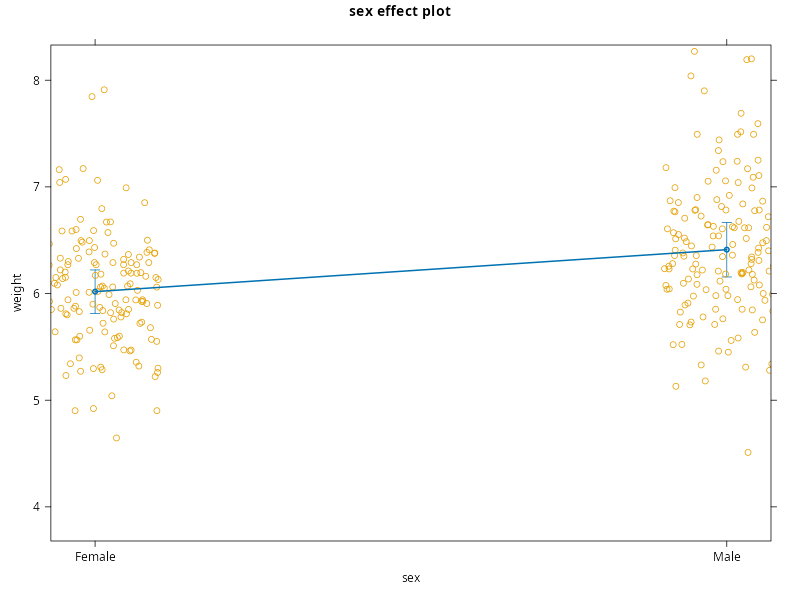

In [5]:
library('emmeans')
library('effects')

emm    <- emmeans(lme.ratpup, pairwise ~ sex, mode='asymptotic', submodel='type2')
emm.CI <- confint(emm)

print(emm$contrasts)
print(emm.CI$contrasts)

plot(effect('sex', lme.ratpup, residuals=TRUE), partial.residuals=list(smooth=FALSE))

From this we can see that male pups on average were 0.393 grams heavier than female pups, with a 95% confidence interval on the difference of $[0.282 \; 0.504]$. Because 0 sits outside this interval, the lower end of the interval appears meaningful and the test is significant with $p < 0.001$, we conclude that a small but consistent difference in weight between male and female pups likely exists within the population. Some caution is needed here, given that these are *asymptotic* tests and CIs. Although the number of pups is large, the number of litters remains modest and more certainty could only come from sampling more litters. That being said, the treatment appears to not influence pup weight in any detectable fashion, either as a whole or differentially in male and female pups.

### Exploring the Random-effects
Although our inferential job is now done (to the best that we can, given everything we have discussed), it is worth spending some time exploring the model outputs and trying to gain a little more intuition. Notice in the output above that we have a description of the random effects that were fit using `~ 1 + sex|litter`. This is repeated below

```
Random effects:
 Formula: ~1 + sex | litter
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev    Corr  
(Intercept) 0.5019186 (Intr)
sexMale     0.1554335 0.888 
Residual    0.4005464       
```

We can see *three* variance estimates here (given as `StdDev` by taking square-roots), which is what we expect given our previous description of the model we are building. We can also see that `lme()` has *automatically* estimated a correlation between the intercept and the effect of `sex`. This is done by default as a very general modelling assuming, irrespective of the context of the data. This allows for a more flexible covariance structure which, in the current context, captures the idea that the effect of `sex` may relate to the average weight of each litter. For example, it might be that heavier litters also tend to show a larger sex difference in weight. This assumption can be switched *off* if we do not want it, but we almost always want to leave it in place. We will come back to this further below.

We can extract the realised values of the random effects, as shown below.

In [6]:
random.effects(lme.ratpup)

    (Intercept)      sexMale
1   0.283091048  0.066250415
2  -0.153500107 -0.033344540
3   0.701543759  0.178278121
4  -0.135362756 -0.031915416
5   0.340037227  0.105202850
6   0.390393255  0.169711123
7  -0.158110148 -0.063206359
8  -0.440380383 -0.124903334
9  -0.935772451 -0.277784567
10  0.108060557  0.011711707
11 -0.319291431 -0.089044095
12  1.080803194  0.297293631
13 -0.268172395 -0.079082057
14 -0.234212253 -0.069014833
15 -0.004590989 -0.009742578
16  0.030052979 -0.004193467
17 -0.521318592 -0.150524666
18  0.183390270  0.088278074
19  0.110812589  0.022647114
20 -0.057473372 -0.006617124
21 -0.749232516 -0.202209691
22 -0.566187590 -0.160408742
23  0.942642618  0.266500217
24 -0.131482487 -0.035557072
25  0.345791183  0.093074636
26  0.273784479  0.073033835
27 -0.115315687 -0.034433183

Here we can see that each of the 27 litters gets its own intercept and its own effect of `sex`. This is parameterised as it would be in any other regression model, using dummy variables. So there is a constraint in place that makes the intercept the weight of female pups and the slope the difference between male and female pups. In addition, these are *not* mean values, they are *deflections*. So we think of them as more like *errors* or *deviations* from the population estimates. For instance, the weight of female pups in litter 1 lies 0.283 grams above the expected value of the population, with male pups in this litter sitting 0.066 grams further above. By comparison, the weight of female pups in litter 4 lies 0.135 grams *below* the expected value of the population, with male pups in this litter sitting a further 0.032 grams below this point.

Another important aspect to note here is that litter 12 had *no* male pups. Despite this, there is still a random slope of `sex` for this litter, representing the different between male and female pups. 

In [7]:
random.effects(lme.ratpup)[12,]

   (Intercept)   sexMale
12    1.080803 0.2972936

How is this possible? 

This is the process of *pooling* in action. On its own, this litter has no way to estimate a slope. However, the model is not working through each litter separately and fitting an individual regression model. This is a useful mental picture of what is happening, but in reality everything is fit *at the same time*. This means that the model can use information from across *all* litters as well as information from the covariance structure to *infer* what the most probable slope for that litter is, even if the data does not support it. This is one of the most powerful aspects of a mixed-effects model. When data are missing, the remaining information can be used to *infer* the missing values in a principled way. This requires no imputation on the part of the analyst, it is simply part of the framework.

Of importance here is that this *requires* a non-zero correlation to be estimated between the intercept and the slope. Without any male pups, the model has to use the intercept for litter 12 *and* the overall correlation between the intercept and the slope to *predict* what the slope is likely to be. If we force this correlation to be 0, the model has nothing to work with and the estimated slope for litter 12 is shrunk to zero. In this case, the model has no power left to impute missing values. This is another reason why the assumed correlation between the random effects is so important. If we force it to 0, we get 

In [8]:
mod.uncorr <- lme(fixed  =  weight ~ sex*treatment,
                  random = list(litter=pdDiag(~ 1 + sex)), # force correlation between random-effects to 0
                  data   = ratpup
)

random.effects(mod.uncorr)[12,]

   (Intercept) sexMale
12    1.119048       0

It is also worth remembering that it is the *variance of the distribution* of the random-effects that is of important. This what the `StdDev` column in the output table is referring to. We can plot these below so we get a sense that it is the *width* of these various distributions that is of most interest.

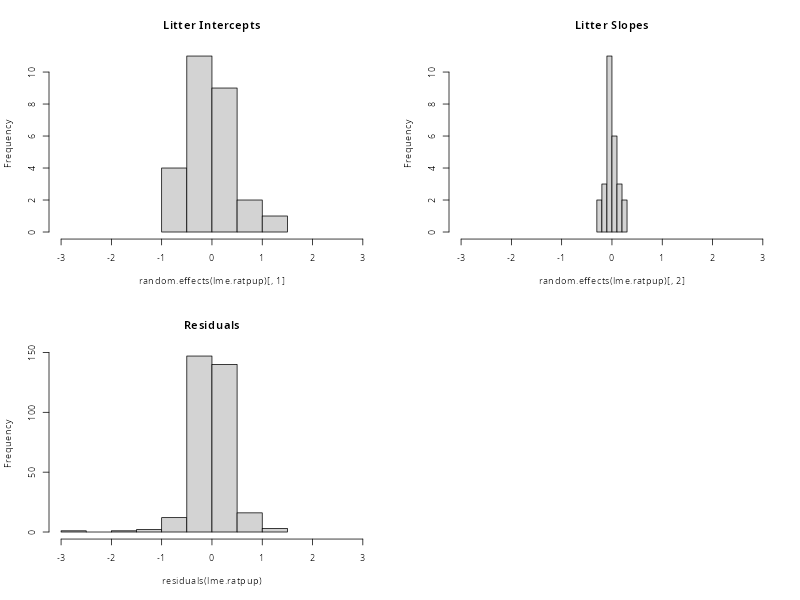

In [9]:
par(mfrow=c(2,2))
hist(random.effects(lme.ratpup)[,1], xlim=c(-3,3), main='Litter Intercepts')
hist(random.effects(lme.ratpup)[,2], xlim=c(-3,3), main='Litter Slopes')
hist(residuals(lme.ratpup), xlim=c(-3,3), main='Residuals')

As we can see, the width of both the intercept and the residual distributions are similar, with the slopes much narrower. This pattern is echoed by the `StdDev` values in the output table.

## The Marginal Covariance Structure
It is also interesting to explore the variance-covariance structure that has been fit. This is a function of the random-effects themselves, rather than being directly specified. However, if we want to think of a mixed-effects model in terms of the marginal covariance structure, we may wish to check that the implied structure is reasonable. 

In the code below, we extract and visualise the covariance block for litter 6

          1         2         3         4         5         6         7
1 0.5751104 0.4146730 0.4146730 0.4146730 0.4146730 0.4146730 0.3212178
2 0.4146730 0.5751104 0.4146730 0.4146730 0.4146730 0.4146730 0.3212178
3 0.4146730 0.4146730 0.5751104 0.4146730 0.4146730 0.4146730 0.3212178
4 0.4146730 0.4146730 0.4146730 0.5751104 0.4146730 0.4146730 0.3212178
5 0.4146730 0.4146730 0.4146730 0.4146730 0.5751104 0.4146730 0.3212178
6 0.4146730 0.4146730 0.4146730 0.4146730 0.4146730 0.5751104 0.3212178
7 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.4123597
8 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.2519223
9 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.2519223
          8         9
1 0.3212178 0.3212178
2 0.3212178 0.3212178
3 0.3212178 0.3212178
4 0.3212178 0.3212178
5 0.3212178 0.3212178
6 0.3212178 0.3212178
7 0.2519223 0.2519223
8 0.4123597 0.2519223
9 0.2519223 0.4123597


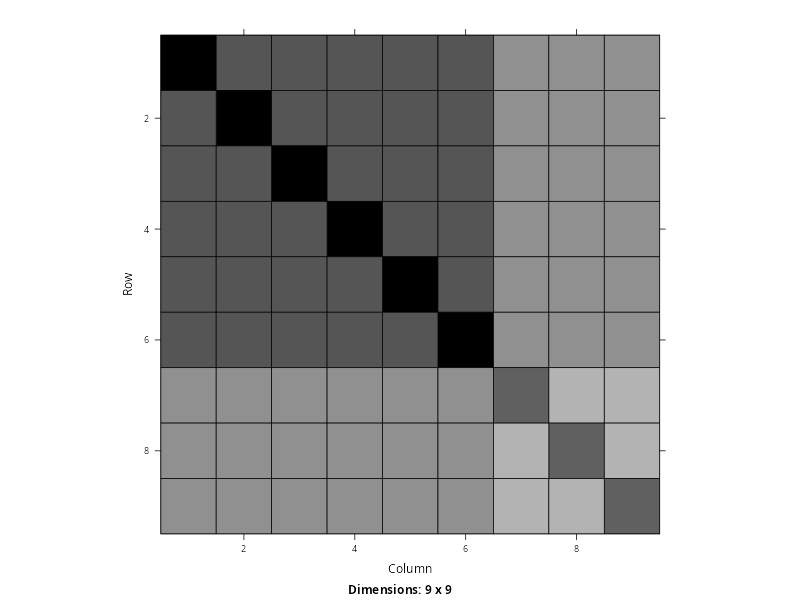

In [10]:
library('Matrix')
Sigma <- getVarCov(lme.ratpup, type="marginal", individual="6")$`6` # Litter 6
print(Sigma)
Matrix::image(as(Sigma,'Matrix'))

As we can see, this litter consisted of 9 pups. The first 6 were *female* and the final 3 were *male*. Here we can see that the covariance structure has resulted in several features:

- Male pups and female pups have different variances 
- All male pups within a litter share the same covariance
- All female pups within a litter share the same covariance
- All male-female pairs within a litter share the same covariance

Importantly, there are *three* different types of dependence represented here: male-male, female-female and female-male. So, all pups within a litter are correlated, but this correlation further depends upon `sex`. This is the essence of including `sex` as a random-effect, alongside the random intercept.

We can expand this further by viewing the full covariance structure, using the `fullVarCov()` function defined in the previous lesson. This gives:

In [11]:
library('Matrix')

fullVarCov <- function(fit) {
  grouping_var_name <- names(fit$groups)[1] # get grouping variable name (e.g "id")
  groups <- fit$data[[grouping_var_name]]   # use name to get grouping variable
  groups <- unique(as.character(groups))    # reduce grouping variable to unique values

  # for each unique grouping variable value, extract the covariance matrices
  blocks <- lapply(groups, function(gi) {
    S <- getVarCov(fit, individual = gi, type = "marginal")
    if (is.list(S)) {
      S <- S[[gi]]
    }
    as.matrix(S)
  })

  # put the covariance matrices into blocks
  V <- bdiag(blocks)
  V
}

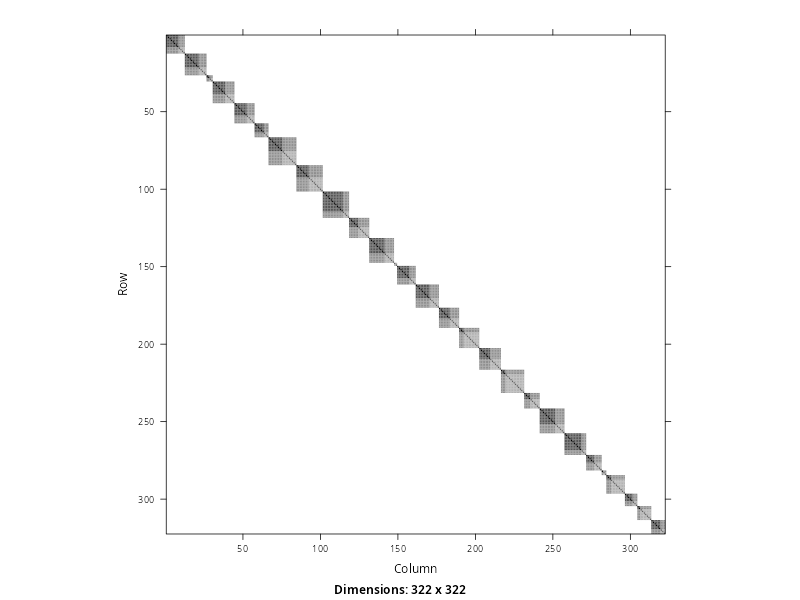

In [12]:
Sigma.Big <- fullVarCov(lme.ratpup)
image(Sigma.Big)

Here we can see how the size of each litter corresponds to the dimensions of its covariance block. For instance, litter 3 is very small whereas litter 7 is quite large. Within each covariance block, we can also see the patterns that correspond to the male pups, the female pups and the correlation between them. In addition, notice that the covariance structure is 0 between litters. This is why we considered litter to be the "boundary of dependency". Everything *within* a litter is correlated, everything *between* litters is independent. In effect, `litter` is being treated the same way that `subject` would be treated under repeated measurements.

## Should `sex` be Fixed or Random?
As a final topic, we will return to the topic of whether `sex` should be treated as a *fixed-effect* or a *random-effect*. Earlier we discussed how an argument could be made either way, so now we actually investigate what the data suggest about these options. Below, we fit a model *with* and *without* `sex` in the random-effects structure and compare them[^lmecontrol-foot].

In [13]:
lme.mod.0 <- lme(weight ~ sex*treatment, random= ~       1|litter, data=ratpup, method='ML', control=lmeControl(opt='optim'))
lme.mod.1 <- lme(weight ~ sex*treatment, random= ~ 1 + sex|litter, data=ratpup, method='ML', control=lmeControl(opt='optim')) 

anova(lme.mod.0,lme.mod.1)

          Model df      AIC      BIC    logLik   Test  L.Ratio p-value
lme.mod.0     1  8 425.9672 456.1636 -204.9836                        
lme.mod.1     2 10 425.2734 463.0189 -202.6367 1 vs 2 4.693801  0.0957

As discussed previously, we tend to prefer BIC here due to its greater sensitivity to the number of parameters. The change in BIC between these models is $\Delta_{\text{BIC}} = 463.0189 - 456.1663 = 6.8526$. Given our interpretational criteria from last semester, this suggests *strong evidence* in favour of the *lower* BIC model. So, it seems the data suggest that the more parsimonious model is 

In [14]:
lme.ratpup <- lme(fixed  = weight ~ 1 + treatment + sex + sex:treatment, # fixed-effects 
                  random =        ~ 1|litter,                            # random-effects
                  data   = ratpup
)  

We can then run through the fixed-effects inference process again to see if this has altered our conclusions.

By way of visual comparison, the plots below show the litter-specific models under each assumption. Notice that `ggplot2` will complain because litter 12 is missing male pups. This can be safely ignored, but could be a useful indicator if this had not been spotted prior to this point.

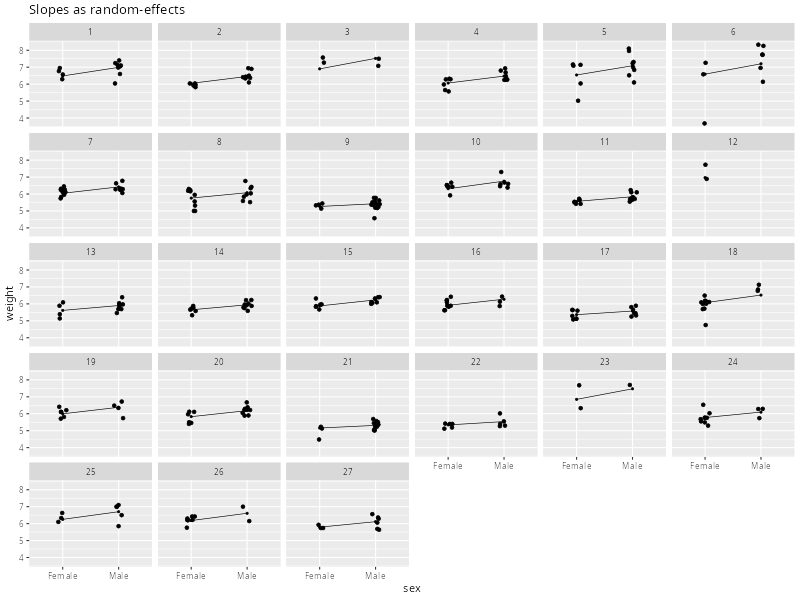

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?

In [15]:
library(ggplot2)

mod.1         <- lme(weight ~ sex*treatment, random= ~ 1 + sex|litter, data=ratpup)  
plot.data     <- ratpup
plot.data$fit <- predict(mod.1, level=1)

ggplot(plot.data, aes(x=sex, y=weight)) +
  geom_point(position=position_jitter(width=0.08, height=0)) +
  stat_summary(aes(y=fit, group=litter), fun=mean, geom="line",  linewidth=0.3) +
  stat_summary(aes(y=fit, group=litter), fun=mean, geom="point", size=0.8) +
  facet_wrap(~ litter) + 
  labs(title='Slopes as random-effects')

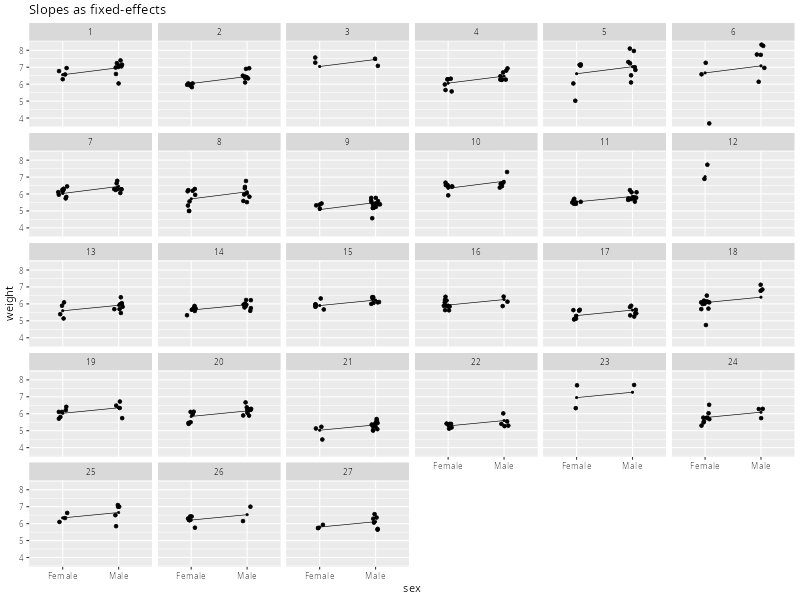

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?

In [16]:
library(ggplot2)

mod.2         <- lme(weight ~ sex*treatment, random= ~ 1|litter, data=ratpup)  
plot.data     <- ratpup
plot.data$fit <- predict(mod.2, level=1)

ggplot(plot.data, aes(x=sex, y=weight)) +
  geom_point(position=position_jitter(width=0.08, height=0)) +
  stat_summary(aes(y=fit, group=litter), fun=mean, geom="line",  linewidth=0.3) +
  stat_summary(aes(y=fit, group=litter), fun=mean, geom="point", size=0.8) +
  facet_wrap(~ litter) + 
  labs(title='Slopes as fixed-effects')

[^finalerror-foot]: Although we can write the model sum in any order, you can always tell which term is the final and most fine-grained error term because it will have identical indices to the data. The model is ultimately of the form $y_{ij}^{(k)} = (\text{other terms)} + \eta_{ij}^{(k)}$. So the data and the final error live as a pair because the final error *is* the data, but with all the model predictions removed.

[^lmecontrol-foot]: We have had to adjust some of the computing elements of these models, otherwise they fail to converge. When this happens, especially when we know there is nothing wrong with the model form, we usually try and adjust either the optimisation algorithm being used, or the number of iterations. In this example, we change the optimisation algorithm, as the default in `lme()` can be a bit flaky. If this did not work, we would usually attempt to increase the number of iterations instead. 

[^sextextbook-foot]: It is interesting to note that, in their description of this analysis, [West, Welch & Galecki (2022)](https://www.taylorfrancis.com/books/mono/10.1201/9781003181064/linear-mixed-models-brady-west-kathleen-welch-andrzej-galecki?context=ubx&refId=4dbda113-7f59-4ba9-a710-897ef536cfee) make the decision to fix `sex` to a constant across litters, under the belief that there is a universal effect of `sex` on weight that is not influenced by individual litters.